In [1]:
# Objective: Importing necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppressing warnings for a cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Done!")

Done!


In [ ]:
# Objective: Data Acquisition - Loading the Nifty 50 historical stock data and inspecting its structure
df = pd.read_csv('combined_nifty_50_data.csv')

# To view the first 5 rows of data
print("First 5 rows of the dataset:")
display(df.head())

# To check the data structure and missing values
print("\n--- Data Information ---")
df.info()

First 5 rows of the dataset:


,Date,Open,High,Low,Close,Adj Close,Volume,VWAP,Stock,Price
0,02-07-2002,15.379487,16.343575,15.379487,16.297667,15.277594,664008.0,16.00690967,BHARTI_AIRTEL,NaN
1,03-07-2002,16.527210,16.527210,16.045168,16.136984,15.126969,564071.0,16.236454,BHARTI_AIRTEL,NaN
2,04-07-2002,16.412437,16.641981,16.182894,16.527210,15.492774,1127138.0,16.450695,BHARTI_AIRTEL,NaN
3,05-07-2002,16.091076,16.274712,15.609032,15.700850,14.718133,886627.0,15.86153133,BHARTI_AIRTEL,NaN
4,08-07-2002,15.723804,15.930394,15.494260,15.609032,14.632062,561511.0,15.67789533,BHARTI_AIRTEL,NaN



--- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 238885 entries, 0 to 238884
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date       238884 non-null  str    
 1   Open       238485 non-null  float64
 2   High       238485 non-null  float64
 3   Low        238485 non-null  float64
 4   Close      238485 non-null  float64
 5   Adj Close  234628 non-null  float64
 6   Volume     234628 non-null  float64
 7   VWAP       238884 non-null  str    
 8   Stock      238885 non-null  str    
 9   Price      1378 non-null    float64
dtypes: float64(7), str(3)
memory usage: 18.2 MB


In [4]:
# Objective: Data Cleaning - Removing unnecessary columns, handling missing values, and formatting dates

# 1. Deleting the 'Price' column because almost all its values ​​are missing.
if 'Price' in df.columns:
    df = df.drop(columns=['Price'])

# 2. Converting the date column to the proper datetime format.
# `errors='coerce'` will convert invalid dates into NaT (Not a Time).
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True, errors='coerce')

# 3. Deleting the remaining rows containing missing values ​​(NaN or NaT) to ensure the data is completely clean.
df = df.dropna()

# 4. Sorting the data by stock and date (so that older dates appear first and newer ones later)
df = df.sort_values(by=['Stock', 'Date'])

# Let's check what the data looks like after cleaning.
print("The data cleaning was completely successful!")
print("\n--- New Data Information ---")
df.info()

print("\n--- How many missing values ​​are left now? ---")
display(df.isnull().sum())

The data cleaning was completely successful!

--- New Data Information ---
<class 'pandas.DataFrame'>
Index: 234628 entries, 5222 to 218034
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       234628 non-null  datetime64[us]
 1   Open       234628 non-null  float64       
 2   High       234628 non-null  float64       
 3   Low        234628 non-null  float64       
 4   Close      234628 non-null  float64       
 5   Adj Close  234628 non-null  float64       
 6   Volume     234628 non-null  float64       
 7   VWAP       234628 non-null  str           
 8   Stock      234628 non-null  str           
dtypes: datetime64[us](1), float64(6), str(2)
memory usage: 17.9 MB

--- How many missing values ​​are left now? ---


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
VWAP         0
Stock        0
dtype: int64

In [5]:
# Objective: Strategy Implementation - Calculating 20-day (SMA) and 50-day (LMA) moving averages and generating buy/sell signals

# Calculating 20-day and 50-day moving averages per stock based on the 'Close' price
df['SMA_20'] = df.groupby('Stock')['Close'].transform(lambda x: x.rolling(window=20).mean())
df['LMA_50'] = df.groupby('Stock')['Close'].transform(lambda x: x.rolling(window=50).mean())

# Generating Buy/Sell signals based on the crossover strategy
# Buy signal (1): Short-term MA crosses above Long-term MA
# Sell signal (-1): Short-term MA crosses below Long-term MA
# Hold (0): Default state
df['Signal'] = 0 
df.loc[df['SMA_20'] > df['LMA_50'], 'Signal'] = 1
df.loc[df['SMA_20'] < df['LMA_50'], 'Signal'] = -1

print("Moving Averages and Signals generated successfully!")

# Displaying a sample of the data to verify the new columns
print("\nSample Data with SMA, LMA, and Signals:")
display(df[['Date', 'Stock', 'Close', 'SMA_20', 'LMA_50', 'Signal']].tail(10))

Moving Averages and Signals generated successfully!

Sample Data with SMA, LMA, and Signals:


,Date,Stock,Close,SMA_20,LMA_50,Signal
218025,2023-06-12,WIPRO,395.600006,397.220001,383.167000,1
218026,2023-06-13,WIPRO,395.549988,397.650000,383.953999,1
218027,2023-06-14,WIPRO,396.450012,398.357501,384.702000,1
218028,2023-06-15,WIPRO,388.950012,398.675002,385.176000,1
218029,2023-06-16,WIPRO,381.299988,398.430000,385.442999,1
218030,2023-06-19,WIPRO,380.149994,397.650000,385.650999,1
218031,2023-06-20,WIPRO,382.500000,396.892500,385.967999,1
218032,2023-06-21,WIPRO,385.500000,396.182500,386.212000,1
218033,2023-06-22,WIPRO,382.299988,395.592499,386.452999,1
218034,2023-06-23,WIPRO,379.950012,394.504999,386.609000,1


In [6]:
# Objective: Calculating Daily Returns and Strategy Returns for performance evaluation

# 1. Calculate daily percentage change (returns) for each stock based on Close price
df['Daily_Return'] = df.groupby('Stock')['Close'].pct_change()

# 2. Calculate strategy returns by shifting the signal by 1 day
# (Since the trading signal is generated at the end of the day, the return is realized the next day)
df['Strategy_Return'] = df.groupby('Stock')['Signal'].shift(1) * df['Daily_Return']

# 3. Extract the 'Year' from the Date column to create the required yearly breakdown later
df['Year'] = df['Date'].dt.year

print("Daily Returns, Strategy Returns, and Year extracted successfully!")

# Displaying a sample to verify the calculations
display(df[['Date', 'Stock', 'Close', 'Signal', 'Daily_Return', 'Strategy_Return', 'Year']].tail(10))

Daily Returns, Strategy Returns, and Year extracted successfully!


,Date,Stock,Close,Signal,Daily_Return,Strategy_Return,Year
218025,2023-06-12,WIPRO,395.600006,1,-0.004279,-0.004279,2023
218026,2023-06-13,WIPRO,395.549988,1,-0.000126,-0.000126,2023
218027,2023-06-14,WIPRO,396.450012,1,0.002275,0.002275,2023
218028,2023-06-15,WIPRO,388.950012,1,-0.018918,-0.018918,2023
218029,2023-06-16,WIPRO,381.299988,1,-0.019668,-0.019668,2023
218030,2023-06-19,WIPRO,380.149994,1,-0.003016,-0.003016,2023
218031,2023-06-20,WIPRO,382.500000,1,0.006182,0.006182,2023
218032,2023-06-21,WIPRO,385.500000,1,0.007843,0.007843,2023
218033,2023-06-22,WIPRO,382.299988,1,-0.008301,-0.008301,2023
218034,2023-06-23,WIPRO,379.950012,1,-0.006147,-0.006147,2023


In [7]:
# Objective: Calculating key performance metrics on a yearly basis (Total Return, Annualized Return, Max Drawdown, Sharpe Ratio, Win/Loss, Trades)

def calculate_metrics(df_group):
    strat_returns = df_group['Strategy_Return'].dropna()
    
    # 1. Total Return
    total_return = (1 + strat_returns).prod() - 1
    
    # 2. Annualized Return
    trading_days = len(strat_returns)
    annualized_return = (1 + total_return) ** (252 / trading_days) - 1 if trading_days > 0 else 0
    
    # 3. Maximum Drawdown
    cum_returns = (1 + strat_returns).cumprod()
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    max_drawdown = drawdown.min()
    
    # 4. Sharpe Ratio (Assuming Risk-Free Rate = 0)
    mean_return = strat_returns.mean()
    std_return = strat_returns.std()
    sharpe_ratio = (mean_return / std_return) * np.sqrt(252) if std_return > 0 else 0
    
    # 5. Win/Loss Ratio
    winning_trades = (strat_returns > 0).sum()
    losing_trades = (strat_returns < 0).sum()
    win_loss_ratio = winning_trades / losing_trades if losing_trades > 0 else winning_trades
    
    # 6. Number of Trades Executed
    signals = df_group['Signal']
    num_trades = (signals.diff() != 0).sum()
    
    return pd.Series({
        'Total_Return': total_return,
        'Annualized_Return': annualized_return,
        'Max_Drawdown': max_drawdown,
        'Sharpe_Ratio': sharpe_ratio,
        'Win_Loss_Ratio': win_loss_ratio,
        'Num_Trades': num_trades
    })

# Grouping the data by Stock and Year, then applying the metrics function
yearly_metrics = df.groupby(['Stock', 'Year']).apply(calculate_metrics).reset_index()

print("Performance metrics calculated successfully!")
print("\nSample of Yearly Breakdown of Metrics:")
display(yearly_metrics.head(10))

Performance metrics calculated successfully!

Sample of Yearly Breakdown of Metrics:


,Stock,Year,Total_Return,Annualized_Return,Max_Drawdown,Sharpe_Ratio,Win_Loss_Ratio,Num_Trades
0,ADANI_ENTERPRISES,2002,-0.088443,-0.164315,-0.202992,-0.800446,1.205882,3.0
1,ADANI_ENTERPRISES,2003,0.641997,0.614157,-0.406932,1.181779,1.254545,5.0
2,ADANI_ENTERPRISES,2004,0.161392,0.155416,-0.320499,0.546173,0.967742,7.0
3,ADANI_ENTERPRISES,2005,-0.111273,-0.112111,-0.540974,0.320547,0.889764,15.0
4,ADANI_ENTERPRISES,2006,2.578397,2.671950,-0.430389,2.394223,1.160714,5.0
5,ADANI_ENTERPRISES,2007,3.964617,4.094595,-0.200516,3.356972,1.342857,3.0
6,ADANI_ENTERPRISES,2008,0.603618,0.622196,-0.453414,1.071636,1.067797,4.0
7,ADANI_ENTERPRISES,2009,0.693309,0.726665,-0.322131,1.320275,1.113043,6.0
8,ADANI_ENTERPRISES,2010,-0.098839,-0.099589,-0.271406,-0.098348,0.878788,6.0
9,ADANI_ENTERPRISES,2011,0.274932,0.282507,-0.422745,0.778998,1.178571,5.0


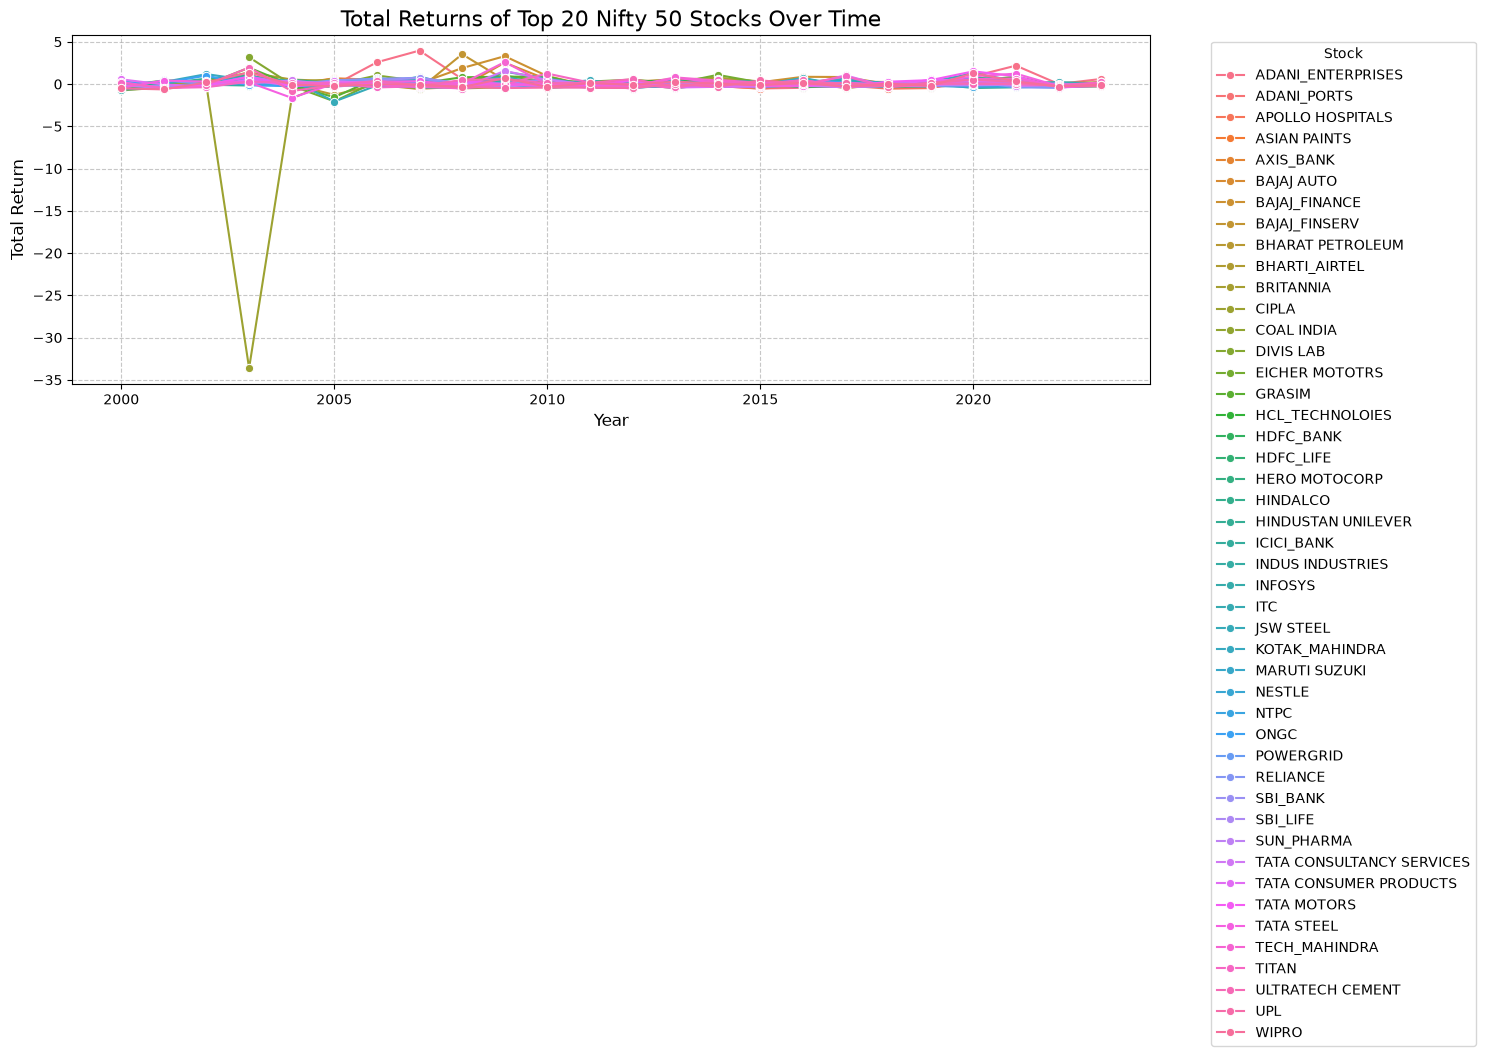

In [8]:
# Objective q1: Visualizing Total Returns for top 20 stocks over time using a line chart

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

# Using seaborn to create a line plot with Year on x-axis, Total_Return on y-axis, colored by Stock
sns.lineplot(data=yearly_metrics, x='Year', y='Total_Return', hue='Stock', marker='o')

plt.title('Total Returns of Top 20 Nifty 50 Stocks Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Return', fontsize=12)
plt.legend(title='Stock', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

First 5 stocks selected: ['ADANI_ENTERPRISES', 'ADANI_PORTS', 'APOLLO HOSPITALS', 'ASIAN PAINTS', 'AXIS_BANK']


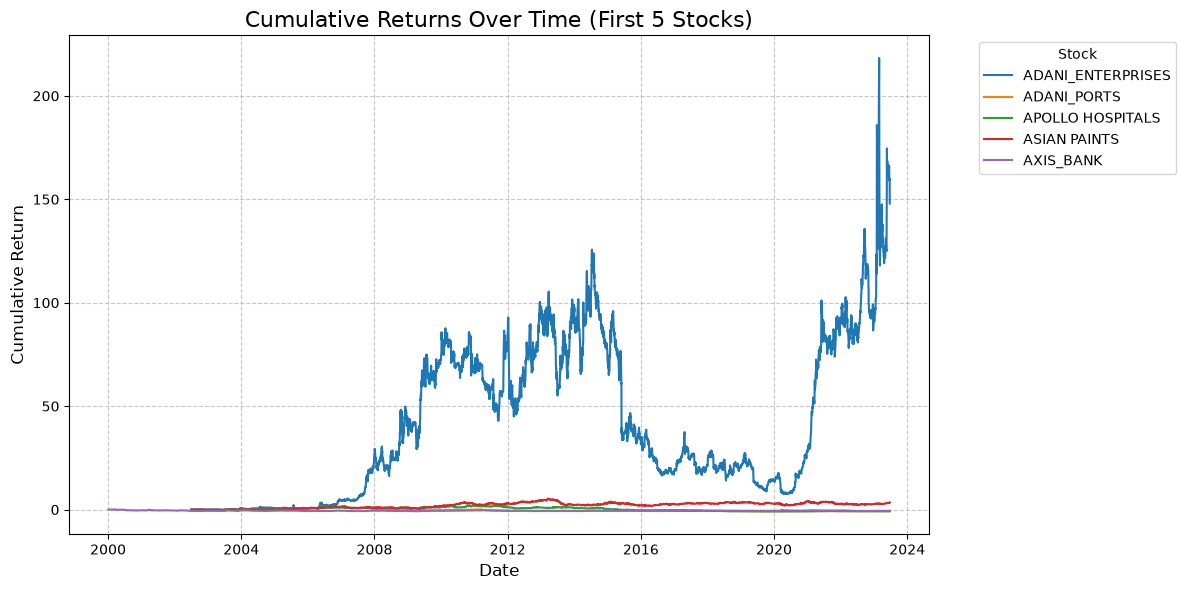

In [9]:
# Objective q1 (Part 2): Visualizing cumulative returns over time for the first 5 stocks

# 1. Get the names of the first 5 stocks after sorting alphabetically
first_5_stocks = sorted(df['Stock'].unique())[:5]
print("First 5 stocks selected:", first_5_stocks)

# 2. Filter the original dataframe to include only these 5 stocks
df_top5 = df[df['Stock'].isin(first_5_stocks)].copy()

# 3. Calculate Cumulative Return (using Strategy_Return)
df_top5['Cumulative_Return'] = df_top5.groupby('Stock')['Strategy_Return'].transform(lambda x: (1 + x).cumprod() - 1)

# 4. Plotting the chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top5, x='Date', y='Cumulative_Return', hue='Stock')

plt.title('Cumulative Returns Over Time (First 5 Stocks)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(title='Stock', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

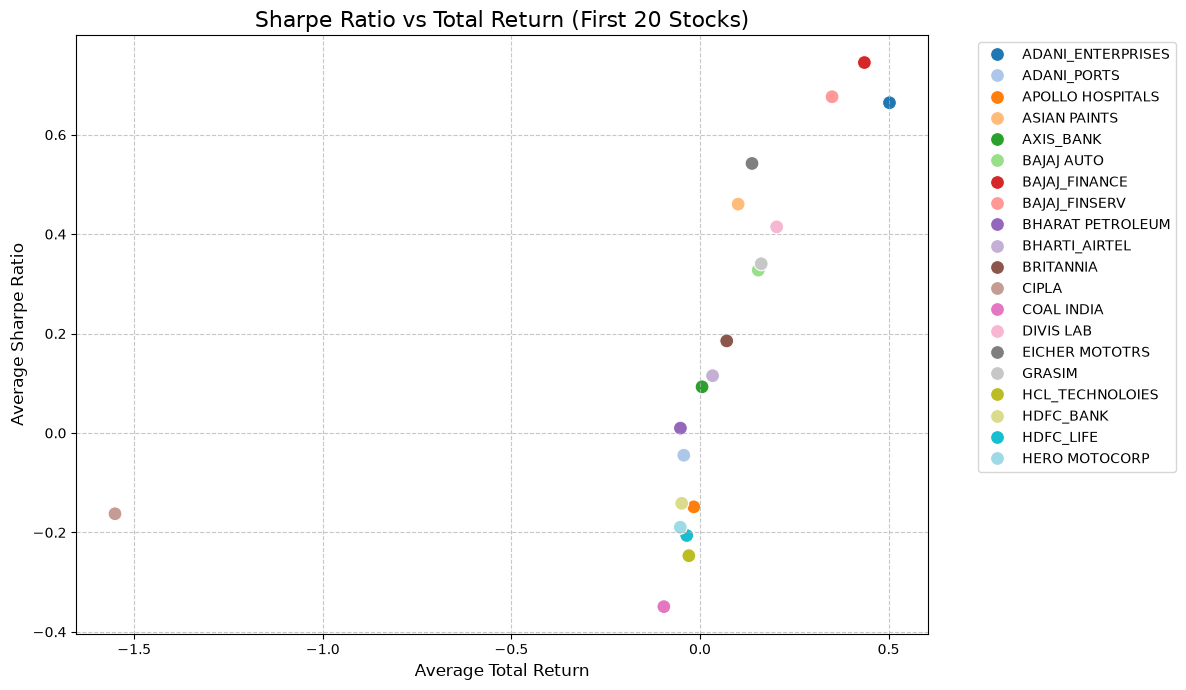

In [10]:
# Objective q1 (Part 3): Scatter plot of Sharpe Ratio vs. Total Return for the first 20 stocks

# 1. First, we need to calculate the overall Total Return and Sharpe Ratio for each stock across all years
# We already have yearly_metrics, let's aggregate it to get one value per stock
stock_overall_metrics = yearly_metrics.groupby('Stock').agg({
    'Total_Return': 'mean',
    'Sharpe_Ratio': 'mean',
    'Max_Drawdown': 'mean'
}).reset_index()

# 2. Sort the data alphabetically by Stock and select the first 20
first_20_stocks = stock_overall_metrics.sort_values(by='Stock').head(20)

# 3. Plotting the scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=first_20_stocks, x='Total_Return', y='Sharpe_Ratio', hue='Stock', s=100, palette='tab20')

plt.title('Sharpe Ratio vs Total Return (First 20 Stocks)', fontsize=16)
plt.xlabel('Average Total Return', fontsize=12)
plt.ylabel('Average Sharpe Ratio', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

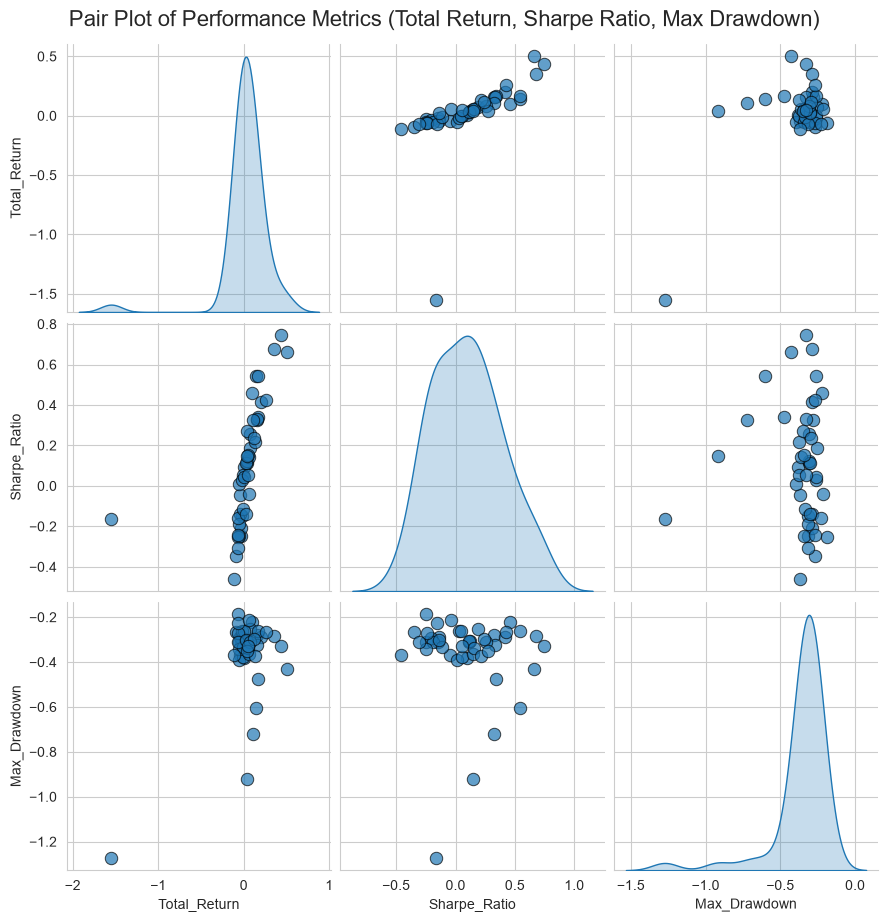


--- Insights from Pair Plot ---
1. Total Return & Sharpe Ratio: Usually, there's a positive correlation. Higher returns often come with higher Sharpe ratios, but not always if volatility is too high.
2. Total Return & Max Drawdown: Higher returns might be associated with deeper max drawdowns (higher risk).
3. Sharpe Ratio & Max Drawdown: Stocks with better Sharpe ratios generally tend to have less severe (closer to 0) max drawdowns.


In [11]:
# Objective q2: Generate a pair plot of selected performance metrics (total return, Sharpe ratio, max drawdown)

# 1. We will use the stock_overall_metrics that we created in the previous step
# It already has the average Total_Return, Sharpe_Ratio, and Max_Drawdown for each stock

# 2. Select only the numeric columns needed for the pair plot
metrics_for_pairplot = stock_overall_metrics[['Total_Return', 'Sharpe_Ratio', 'Max_Drawdown']]

# 3. Create the pair plot using seaborn
sns.set_style("whitegrid")
pair_plot = sns.pairplot(metrics_for_pairplot, 
                         diag_kind='kde', # 'kde' shows the distribution curve on the diagonal
                         plot_kws={'alpha':0.7, 's':80, 'edgecolor':'k'},
                         height=3)

# 4. Adding a title to the entire figure
pair_plot.fig.suptitle('Pair Plot of Performance Metrics (Total Return, Sharpe Ratio, Max Drawdown)', y=1.02, fontsize=16)

# Display the plot
plt.show()

# Brief insight to answer the subjective part of the question
print("\n--- Insights from Pair Plot ---")
print("1. Total Return & Sharpe Ratio: Usually, there's a positive correlation. Higher returns often come with higher Sharpe ratios, but not always if volatility is too high.")
print("2. Total Return & Max Drawdown: Higher returns might be associated with deeper max drawdowns (higher risk).")
print("3. Sharpe Ratio & Max Drawdown: Stocks with better Sharpe ratios generally tend to have less severe (closer to 0) max drawdowns.")

In [13]:
# Objective q3 to q10: Finding extreme values and aggregations for performance metrics

print("--- Answers to Objective Questions (Q3 to Q10) ---")

# q3. Which stock has shown the highest total return over the analyzed period?
# We use the stock_overall_metrics calculated earlier
highest_return_stock = stock_overall_metrics.loc[stock_overall_metrics['Total_Return'].idxmax()]
print(f"\nQ3. Stock with Highest Total Return: {highest_return_stock['Stock']} (Return: {highest_return_stock['Total_Return']:.2f})")

# q4. Which stock has the lowest maximum drawdown, indicating stability?
# Note: Max Drawdown is a negative number, so 'lowest' magnitude (closest to 0) means highest value mathematically
lowest_drawdown_stock = stock_overall_metrics.loc[stock_overall_metrics['Max_Drawdown'].idxmax()]
print(f"\nQ4. Stock with Lowest Maximum Drawdown (Most Stable): {lowest_drawdown_stock['Stock']} (Drawdown: {lowest_drawdown_stock['Max_Drawdown']:.2f})")

# q5. What are the best and worst months for each stock in terms of returns?
df['Month'] = df['Date'].dt.month
monthly_returns = df.groupby(['Stock', 'Year', 'Month'])['Daily_Return'].sum().reset_index()
avg_monthly_returns = monthly_returns.groupby(['Stock', 'Month'])['Daily_Return'].mean().reset_index()

print("\nQ5. Best and Worst Months per Stock (Showing first 3 for brevity):")
for stock in first_5_stocks[:3]:
    stock_data = avg_monthly_returns[avg_monthly_returns['Stock'] == stock]
    best_month = stock_data.loc[stock_data['Daily_Return'].idxmax()]
    worst_month = stock_data.loc[stock_data['Daily_Return'].idxmin()]
    print(f"  - {stock}: Best Month = {int(best_month['Month'])}, Worst Month = {int(worst_month['Month'])}")

# q6. Which stocks have the highest average trading volume?
avg_volume = df.groupby('Stock')['Volume'].mean().reset_index()
highest_vol_stock = avg_volume.loc[avg_volume['Volume'].idxmax()]
print(f"\nQ6. Stock with Highest Average Trading Volume: {highest_vol_stock['Stock']} (Avg Vol: {highest_vol_stock['Volume']:.0f})")

# q7. What is the total number of trades executed for each stock?
# We sum the Num_Trades from yearly_metrics
total_trades = yearly_metrics.groupby('Stock')['Num_Trades'].sum().reset_index()
print("\nQ7. Total Trades Executed per Stock (Showing first 3):")
display(total_trades.head(3))

# q8. Which stock had the maximum single-day loss (highest negative daily return)?
max_loss_row = df.loc[df['Daily_Return'].idxmin()]
print(f"\nQ8. Stock with Max Single-Day Loss: {max_loss_row['Stock']} (Loss: {max_loss_row['Daily_Return']:.2%}) on {max_loss_row['Date'].date()}")

# q9. Which stock had the maximum single-day gain (highest positive daily return)?
max_gain_row = df.loc[df['Daily_Return'].idxmax()]
print(f"\nQ9. Stock with Max Single-Day Gain: {max_gain_row['Stock']} (Gain: {max_gain_row['Daily_Return']:.2%}) on {max_gain_row['Date'].date()}")

# q10. Which stock had the lowest average closing price over the analysis period?
avg_close = df.groupby('Stock')['Close'].mean().reset_index()
lowest_close_stock = avg_close.loc[avg_close['Close'].idxmin()]
print(f"\nQ10. Stock with Lowest Average Closing Price: {lowest_close_stock['Stock']} (Avg Price: {lowest_close_stock['Close']:.2f})")

--- Answers to Objective Questions (Q3 to Q10) ---

Q3. Stock with Highest Total Return: ADANI_ENTERPRISES (Return: 0.50)

Q4. Stock with Lowest Maximum Drawdown (Most Stable): NESTLE (Drawdown: -0.19)

Q5. Best and Worst Months per Stock (Showing first 3 for brevity):
  - ADANI_ENTERPRISES: Best Month = 5, Worst Month = 2
  - ADANI_PORTS: Best Month = 4, Worst Month = 6
  - APOLLO HOSPITALS: Best Month = 11, Worst Month = 3

Q6. Stock with Highest Average Trading Volume: TATA STEEL (Avg Vol: 71141650)

Q7. Total Trades Executed per Stock (Showing first 3):


,Stock,Num_Trades
0,ADANI_ENTERPRISES,124.0
1,ADANI_PORTS,99.0
2,APOLLO HOSPITALS,148.0



Q8. Stock with Max Single-Day Loss: BAJAJ_FINSERV (Loss: -92.65%) on 2008-05-26

Q9. Stock with Max Single-Day Gain: CIPLA (Gain: 1224.17%) on 2003-11-27

Q10. Stock with Lowest Average Closing Price: TATA STEEL (Avg Price: 43.32)


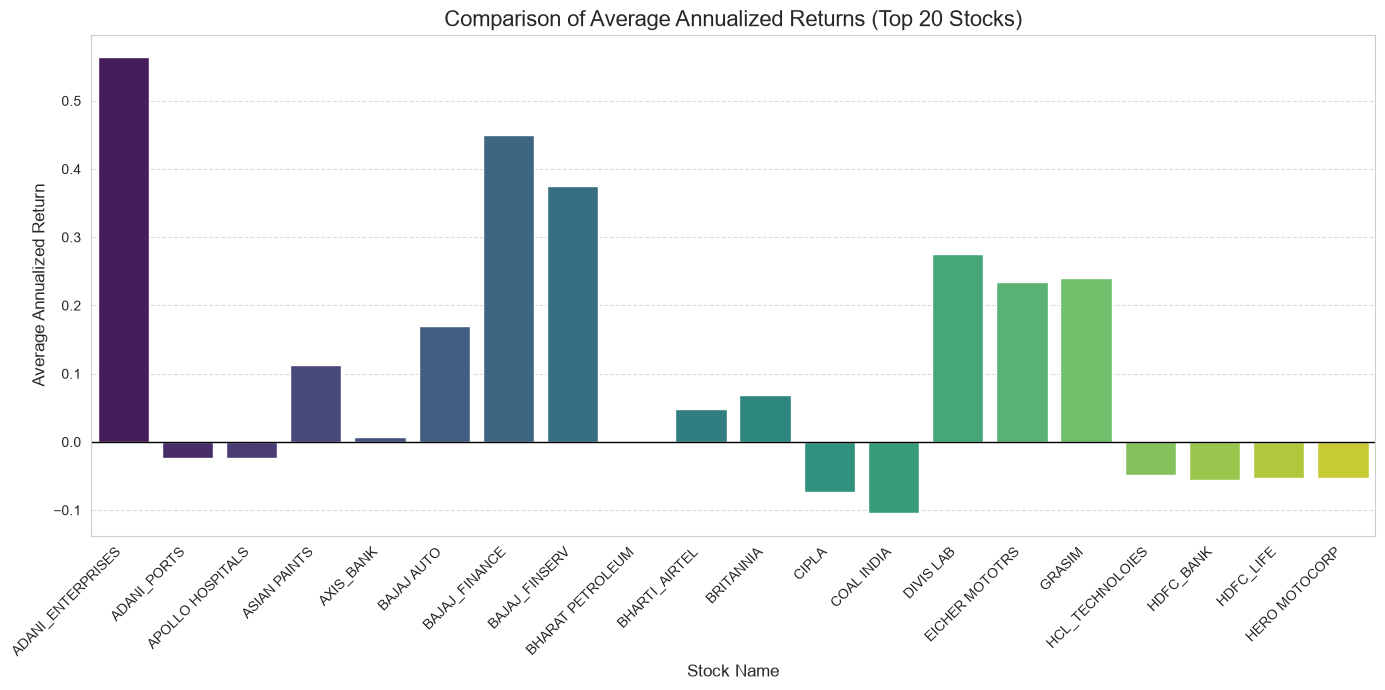

In [18]:
# Objective: Subjective Q1 - Compare annualized returns across the top 20 stocks

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the average annualized return for each stock across all years
annualized_overall = yearly_metrics.groupby('Stock')['Annualized_Return'].mean().reset_index()

# 2. Sort the data alphabetically and pick the first 20 stocks
top_20_annualized = annualized_overall.sort_values(by='Stock').head(20)

# 3. Plotting the Bar Chart
plt.figure(figsize=(14, 7))
sns.barplot(data=top_20_annualized, x='Stock', y='Annualized_Return', palette='viridis')

# Formatting the chart
plt.title('Comparison of Average Annualized Returns (Top 20 Stocks)', fontsize=16)
plt.xlabel('Stock Name', fontsize=12)
plt.ylabel('Average Annualized Return', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate stock names so they don't overlap
plt.axhline(0, color='black', linewidth=1) # Draw a baseline at 0
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

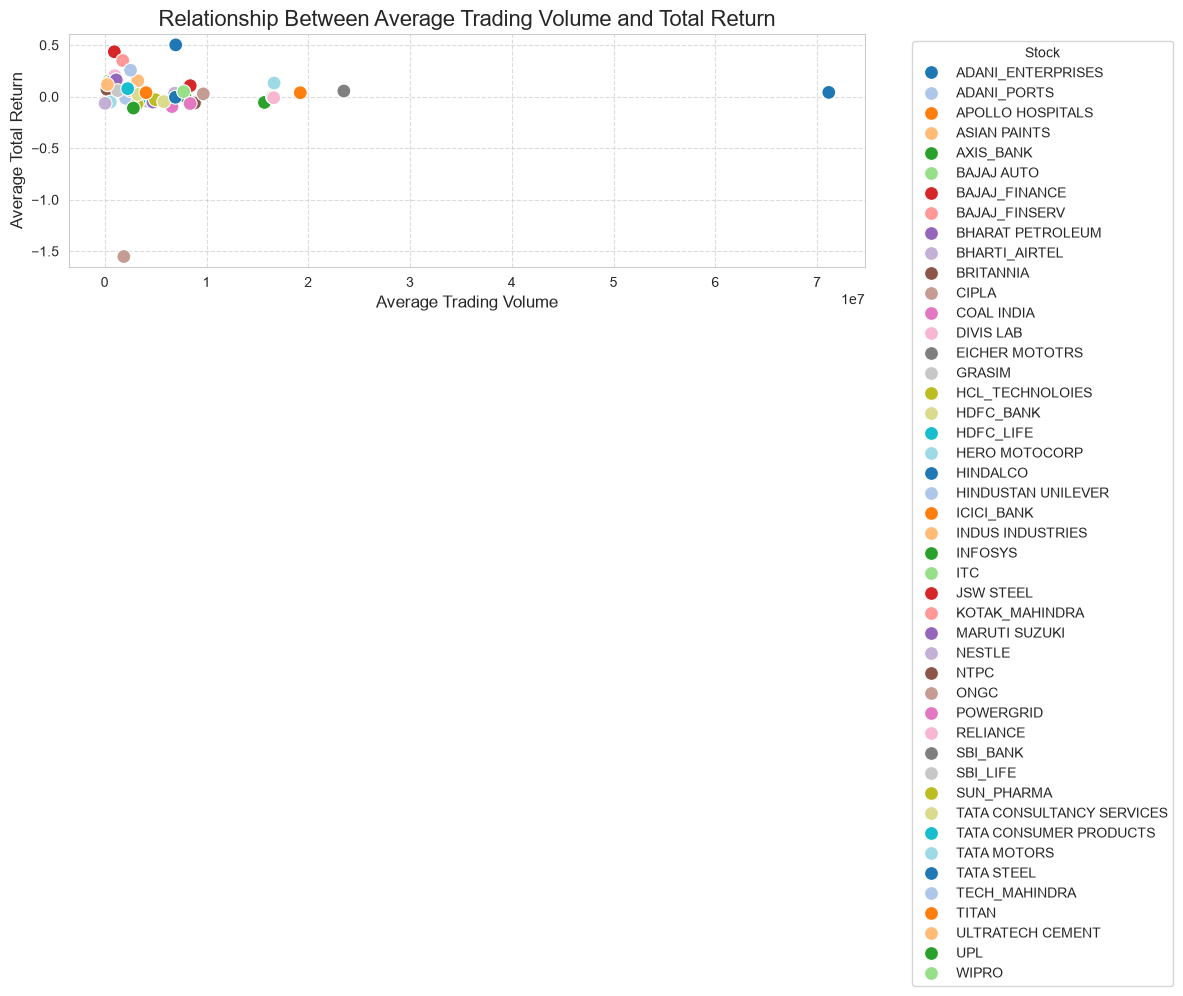

In [19]:
# Objective: Subjective Q2 - Analyze the relationship between total return and trading volume

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate average trading volume per stock across the entire dataset
avg_volume = df.groupby('Stock')['Volume'].mean().reset_index()

# 2. Merge this volume data with the overall metrics (which contains Total_Return)
vol_return_df = pd.merge(stock_overall_metrics, avg_volume, on='Stock')

# 3. Plotting the Scatter Plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=vol_return_df, x='Volume', y='Total_Return', hue='Stock', s=100, palette='tab20')

# Formatting the chart
plt.title('Relationship Between Average Trading Volume and Total Return', fontsize=16)
plt.xlabel('Average Trading Volume', fontsize=12)
plt.ylabel('Average Total Return', fontsize=12)
plt.legend(title='Stock', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

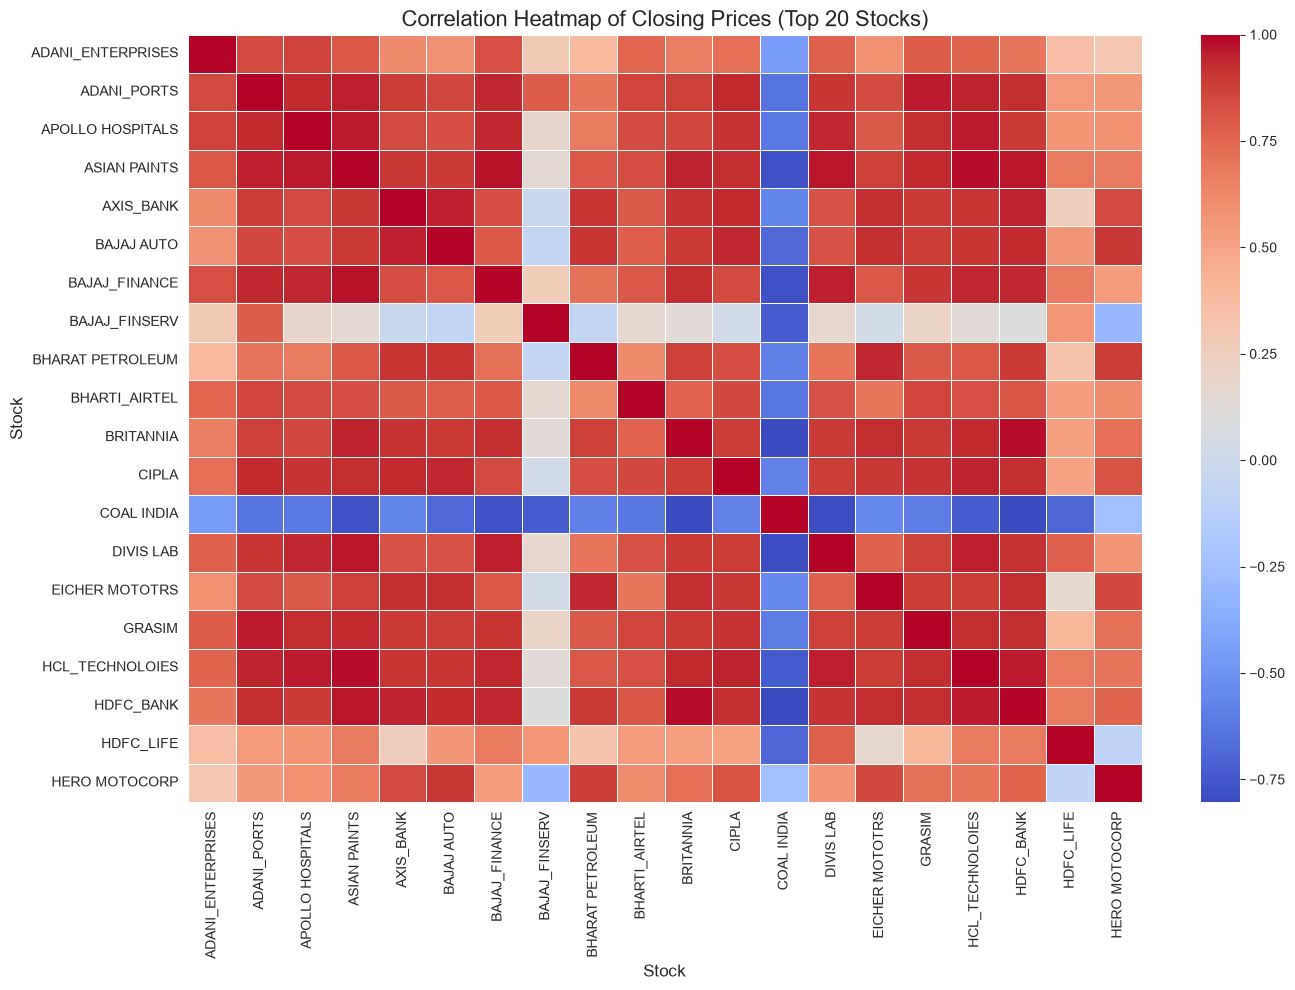


--- Python Coding Complete! ---
Red/Warm colors indicate high positive correlation (stocks move together).
Blue/Cool colors indicate negative correlation (stocks move in opposite directions).


In [14]:
# Objective: Subjective Q3 - Generate a heatmap of the correlation matrix for the closing prices of the top 20 stocks

# 1. Filter the main dataframe for the first 20 stocks we identified earlier
top_20_stock_names = first_20_stocks['Stock'].tolist()
df_top20 = df[df['Stock'].isin(top_20_stock_names)]

# 2. Create a pivot table with Date as index, Stock as columns, and Close price as values
pivot_close = df_top20.pivot_table(index='Date', columns='Stock', values='Close')

# 3. Calculate the correlation matrix
correlation_matrix = pivot_close.corr()

# 4. Plotting the heatmap
plt.figure(figsize=(14, 10))
# Using annot=False because 20x20 numbers would look too cluttered. The colors will show the correlation.
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap of Closing Prices (Top 20 Stocks)', fontsize=16)
plt.xlabel('Stock', fontsize=12)
plt.ylabel('Stock', fontsize=12)
plt.tight_layout()

# Display the plot
plt.show()

print("\n--- Python Coding Complete! ---")
print("Red/Warm colors indicate high positive correlation (stocks move together).")
print("Blue/Cool colors indicate negative correlation (stocks move in opposite directions).")